In [10]:
# Cell 1: Imports & Setup
from pathlib import Path
import json
import shutil
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import optuna
import gc

data_base_dir = Path('data/regionwise_yearwise_samples')
artifact_dir = Path('data/feature_selection_artifacts')
output_config_dir = Path('data/optuna_regional_gee_configs')
output_config_dir.mkdir(parents=True, exist_ok=True)

TARGET_REGION = 'DES'
REGION_DIR = data_base_dir / TARGET_REGION
# BENCHMARK_YEARS = [1995, 2005, 2015, 2024]
# Stratified 8-year temporal anchors covering 1990-2024
BENCHMARK_YEARS = [
    1990,  # Landsat-5 TM baseline (historical baseline)
    1995,  # Landsat-5 TM mid-90s regime
    2000,  # Pre-SLC failure baseline / Turn of century
    2002,  # Major all-India severe drought year (extreme dry spectral endmember)
    2006,  # Landsat-7 ETM+ SLC-off era
    2013,  # Landsat-8 OLI introduction era
    2019,  # High-monsoon/excess rainfall year (extreme wet/vegetative endmember)
    2024   # Modern Landsat-8/9 + Sentinel-2 composite era
]

cache_dir = Path(f'data/cache_splits_{TARGET_REGION}')
if cache_dir.exists():
    shutil.rmtree(cache_dir)
cache_dir.mkdir(parents=True, exist_ok=True)

# Load feature artifacts from 3a and 3b
with open(artifact_dir / f"{TARGET_REGION}_ranked_features.json", "r") as f:
    all_ranked = json.load(f)["ranked_features"]

with open(artifact_dir / f"{TARGET_REGION}_uncorrelated_features.json", "r") as f:
    uncorr_ranked = json.load(f)["uncorrelated_features"]

print(f"Loaded {len(all_ranked)} ranked features, {len(uncorr_ranked)} uncorrelated features.")

Loaded 104 ranked features, 36 uncorrelated features.


In [2]:
# Cell 2: Pre-Partition Benchmark Years into Compressed Split Caches
old_codes = [5, 3, 4, 12, 11, 66, 19, 36, 9, 41, 24, 23, 75, 30, 25, 33, 76, 34, 61]
new_codes = [5, 3, 4, 12, 11, 66, 19, 14, 14, 14, 22, 22, 22, 22, 22, 33, 76, 34, 61]
class_remap_dict = dict(zip(old_codes, new_codes))

print("Loading benchmark years individually from year partitions...")

for yr in BENCHMARK_YEARS:
    year_path = REGION_DIR / f"year={yr}"
    
    # Read ONLY this single year folder off disk
    df_yr = (
        pl.read_parquet(year_path / "*.parquet")
        .with_columns(
            pl.col('class').replace_strict(class_remap_dict, default=pl.col('class')).cast(pl.Int32)
        )
        .select(all_ranked + ['class'])
    )
    
    X_yr = df_yr.select(all_ranked).to_numpy().astype(np.float32)
    y_yr = df_yr['class'].to_numpy().astype(np.int32)
    
    del df_yr
    gc.collect()
    
    # 80:20 Stratified Split per year (locked validation fold)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_yr, y_yr, test_size=0.20, stratify=y_yr, random_state=42
    )
    
    # Save compact binary split cache
    np.savez_compressed(
        cache_dir / f"split_{yr}.npz",
        X_tr=X_tr, y_tr=y_tr, X_val=X_val, y_val=y_val
    )
    print(f"  Cached year {yr}: Train={X_tr.shape[0]:,}, Val={X_val.shape[0]:,}")
    
    del X_yr, y_yr, X_tr, X_val, y_tr, y_val
    gc.collect()

print("Partitioning complete. Memory fully cleared.")

Loading benchmark years individually from year partitions...
  Cached year 1995: Train=93,876, Val=23,470
  Cached year 2005: Train=93,909, Val=23,478
  Cached year 2015: Train=93,909, Val=23,478
  Cached year 2024: Train=93,909, Val=23,478
Partitioning complete. Memory fully cleared.


In [3]:
# Cell 3: Reference Balancing Setup
feat_to_idx = {name: i for i, name in enumerate(all_ranked)}

ref_csv_path = Path('data/classwise_samples_reference_ratios.csv')
ref_df = pd.read_csv(ref_csv_path)
ref_df['old_code'] = old_codes
ref_df['new_code'] = new_codes
ref_region_cols = [c for c in ref_df.columns if c not in ['l2_code', 'l2_name', 'l1_parent', 'old_code', 'new_code']]
parent_ref_df = ref_df.groupby('new_code')[ref_region_cols].sum()
ref_col_series = parent_ref_df[TARGET_REGION] if TARGET_REGION in parent_ref_df.columns else None

def get_balanced_indices(y_train_arr, target_n, ref_series, rng):
    classes = np.unique(y_train_arr)
    col_present = ref_series.reindex(classes).fillna(0.0)
    scaled = (np.sqrt(col_present) / sum(np.sqrt(col_present))) * target_n
    selected = []
    for cls in classes:
        cls_idx = np.where(y_train_arr == cls)[0]
        desired = int(np.round(scaled.get(cls, 0)))
        n_sample = min(len(cls_idx), max(3, desired))
        selected.extend(rng.choice(cls_idx, size=n_sample, replace=False))
    return np.array(selected)

In [4]:
# Cell 4: Multi-Objective Optuna Study Loop (Matching EE smileRandomForest Defaults)
def objective(trial):
    sampling_strategy = trial.suggest_categorical(
        "sampling_strategy", ["stratified", "reference_balanced"]
    )
    
    feat_strategy = trial.suggest_categorical("feature_strategy", ["all", "uncorrelated"])
    if feat_strategy == "uncorrelated":
        active_names = uncorr_ranked
    else:
        num_bands = trial.suggest_int("max_input_features", 10, len(all_ranked))
        active_names = all_ranked[:num_bands]
        
    active_col_idx = [feat_to_idx[f] for f in active_names]
    train_fraction = trial.suggest_float("train_fraction", 0.20, 1.0, step=0.20)

    min_leaf = trial.suggest_int("minLeafPopulation", 2, 12)
    n_trees = trial.suggest_int("numberOfTrees", 50, 150, step=25)

    # Strictly matches GEE smileRandomForest defaults:
    # - max_depth=None (unbounded tree growth matching GEE Smile)
    # - max_features="sqrt" (matches GEE variablesPerSplit default)
    rf_params = {
        "n_estimators": n_trees,
        "min_samples_leaf": min_leaf,
        "max_features": "sqrt",
        "max_depth": None,
        "n_jobs": 2,
        "random_state": 42
    }

    yearly_macro_f1s = []
    total_samples_trained = 0
    all_year_max_nodes = []
    rng = np.random.RandomState(42)

    for yr in BENCHMARK_YEARS:
        # Load only this year's cached split
        data = np.load(cache_dir / f"split_{yr}.npz")
        X_tr = data['X_tr']
        y_tr = data['y_tr']
        X_val = data['X_val'][:, active_col_idx]
        y_val = data['y_val']

        target_n = int(len(X_tr) * train_fraction)

        if train_fraction >= 0.99 and sampling_strategy == "stratified":
            chosen_local = np.arange(len(X_tr))
        elif sampling_strategy == "reference_balanced" and ref_col_series is not None:
            chosen_local = get_balanced_indices(y_tr, target_n, ref_col_series, rng)
        else:
            chosen_local = []
            for cls in np.unique(y_tr):
                cls_indices = np.where(y_tr == cls)[0]
                n_take = max(3, int(target_n * len(cls_indices) / len(y_tr)))
                chosen_local.extend(rng.choice(cls_indices, size=min(len(cls_indices), n_take), replace=False))
            chosen_local = np.array(chosen_local)

        total_samples_trained += len(chosen_local)
        X_sub = X_tr[chosen_local][:, active_col_idx]
        y_sub = y_tr[chosen_local]

        clf = RandomForestClassifier(**rf_params)
        clf.fit(X_sub, y_sub)

        # Extract empirical max node count across trees for this year
        year_max_node = max(tree.tree_.node_count for tree in clf.estimators_)
        all_year_max_nodes.append(year_max_node)

        preds = clf.predict(X_val)
        yearly_macro_f1s.append(f1_score(y_val, preds, average="macro"))

        del data, X_tr, y_tr, X_val, y_val, X_sub, y_sub, clf
        gc.collect()

    mean_macro_f1 = float(np.mean(yearly_macro_f1s))
    max_nodes_observed = int(max(all_year_max_nodes))
    num_features = len(active_col_idx)

    # Multi-Objective Complexity Metric:
    # Samples * Features * Trees * Max Nodes
    model_complexity = float(total_samples_trained * num_features * n_trees * max_nodes_observed)

    # Log metrics to Optuna attributes for inspection and plotting
    trial.set_user_attr("total_samples", total_samples_trained)
    trial.set_user_attr("num_features", num_features)
    trial.set_user_attr("max_nodes", max_nodes_observed)
    trial.set_user_attr("model_complexity", model_complexity)

    return mean_macro_f1, model_complexity

study = optuna.create_study(study_name=f"rf_{TARGET_REGION}", directions=["maximize", "minimize"])
study.optimize(objective, n_trials=40, n_jobs=1)

[I 2026-10-04 17:28:21,997] A new study created in memory with name: rf_DES
[I 2026-10-04 17:29:46,322] Trial 0 finished with values: [0.9313830907762619, 494359842600.0] and parameters: {'sampling_strategy': 'stratified', 'feature_strategy': 'uncorrelated', 'train_fraction': 0.2, 'minLeafPopulation': 7, 'numberOfTrees': 150}.
[I 2026-10-04 17:30:53,685] Trial 1 finished with values: [0.9771599472119169, 503670895000.0] and parameters: {'sampling_strategy': 'stratified', 'feature_strategy': 'all', 'max_input_features': 14, 'train_fraction': 0.4, 'minLeafPopulation': 4, 'numberOfTrees': 100}.
[I 2026-10-04 17:33:19,692] Trial 2 finished with values: [0.9655852276639689, 2132741021400.0] and parameters: {'sampling_strategy': 'stratified', 'feature_strategy': 'uncorrelated', 'train_fraction': 0.8, 'minLeafPopulation': 11, 'numberOfTrees': 75}.
[I 2026-10-04 17:39:01,274] Trial 3 finished with values: [0.958620016386772, 2511391276800.0] and parameters: {'sampling_strategy': 'stratified', 

In [5]:
from optuna.visualization import plot_pareto_front

fig = plot_pareto_front(
    study,
    target_names=["Mean Macro-F1", "Model Complexity"]
)
fig.update_layout(
    title=f"Multi-Objective Pareto Front (F1 vs Model Complexity) - {TARGET_REGION}",
    width=900,
    height=550
)
fig.show()

fig.write_html(output_config_dir / f"{TARGET_REGION}_pareto_frontier.html")

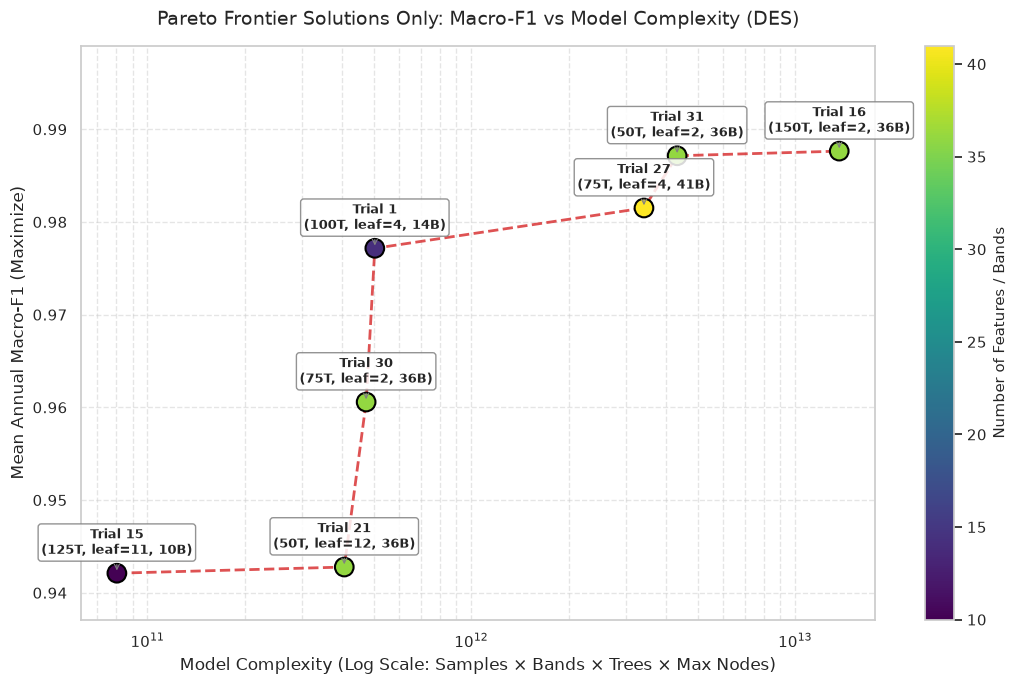


=== Pareto-Optimal Candidates Table ===
 trial_number  macro_f1  model_complexity  total_samples  num_features  trees  min_leaf feature_strat   sampling
           15  0.942111      8.045195e+10          75101            10    125        11           all stratified
           21  0.942778      4.053101e+11         150215            36     50        12  uncorrelated stratified
           30  0.960577      4.734743e+11          75101            36     75         2  uncorrelated stratified
            1  0.977160      5.036709e+11         150215            14    100         4           all stratified
           27  0.981507      3.413841e+12         300458            41     75         4           all stratified
           31  0.987141      4.322214e+12         375603            36     50         2  uncorrelated stratified
           16  0.987642      1.368464e+13         375603            36    150         2  uncorrelated stratified


In [16]:
# --- Dedicated Pareto Frontier Inspection Plot ---

# 1. Filter specifically to Pareto-optimal trials
pareto_records = []
for t in study.best_trials:
    strat = t.params.get("feature_strategy", "all")
    if strat == "uncorrelated":
        n_feats = len(uncorr_ranked)
    else:
        n_feats = t.params.get("max_input_features", len(all_ranked))
        
    pareto_records.append({
        "trial_number": t.number,
        "macro_f1": float(t.values[0]),
        "model_complexity": float(t.values[1]),
        "total_samples": t.user_attrs.get("total_samples"),
        "num_features": t.user_attrs.get("num_features", n_feats),
        "max_nodes": t.user_attrs.get("max_nodes"),
        "trees": t.params.get("numberOfTrees"),
        "min_leaf": t.params.get("minLeafPopulation"),
        "sampling": t.params.get("sampling_strategy"),
        "feature_strat": strat,
        "train_fraction": t.params.get("train_fraction")
    })

df_pareto = pd.DataFrame(pareto_records).sort_values("model_complexity")

# 2. Render plot
fig, ax = plt.subplots(figsize=(11, 7))

# Draw the step-like boundary across complexity
ax.plot(
    df_pareto["model_complexity"],
    df_pareto["macro_f1"],
    color="#d62728",
    linestyle="--",
    linewidth=2,
    alpha=0.8,
    zorder=2,
    label="Pareto Efficient Frontier"
)

# Scatter points sized by number of trees, colored by feature count
scatter = ax.scatter(
    df_pareto["model_complexity"],
    df_pareto["macro_f1"],
    c=df_pareto["num_features"],
    cmap="viridis",
    s=180,
    edgecolor="black",
    linewidth=1.5,
    zorder=3
)

# Colorbar for feature count
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Number of Features / Bands", fontsize=11)

# Annotate each point with Trial # and core hyperparameters
for _, row in df_pareto.iterrows():
    label_text = f"Trial {int(row['trial_number'])}\n({int(row['trees'])}T, leaf={int(row['min_leaf'])}, {int(row['num_features'])}B)"
    ax.annotate(
        label_text,
        xy=(row["model_complexity"], row["macro_f1"]),
        xytext=(0, 14),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.85),
        arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0", color="gray", lw=0.8)
    )

ax.set_xscale("log")  # Complexity spans orders of magnitude (1e10 to 1e13)
ax.set_title(f"Pareto Frontier Solutions Only: Macro-F1 vs Model Complexity ({TARGET_REGION})", fontsize=14, pad=15)
ax.set_xlabel("Model Complexity (Log Scale: Samples × Bands × Trees × Max Nodes)", fontsize=12)
ax.set_ylabel("Mean Annual Macro-F1 (Maximize)", fontsize=12)
ax.grid(True, which="both", linestyle="--", alpha=0.5)

# Expand margins so annotation boxes don't get clipped
y_margin = (df_pareto["macro_f1"].max() - df_pareto["macro_f1"].min()) * 0.25
ax.set_ylim(df_pareto["macro_f1"].min() - 0.005, df_pareto["macro_f1"].max() + y_margin)

plt.tight_layout()
pareto_only_path = output_config_dir / f"{TARGET_REGION}_pareto_only_frontier.png"
plt.savefig(pareto_only_path, dpi=300, bbox_inches="tight")
plt.show()

# 3. Print a clean summary table of just the Pareto points
print("\n=== Pareto-Optimal Candidates Table ===")
display_cols = ["trial_number", "macro_f1", "model_complexity", "total_samples", "num_features", "trees", "min_leaf", "feature_strat", "sampling"]
print(df_pareto[display_cols].to_string(index=False))

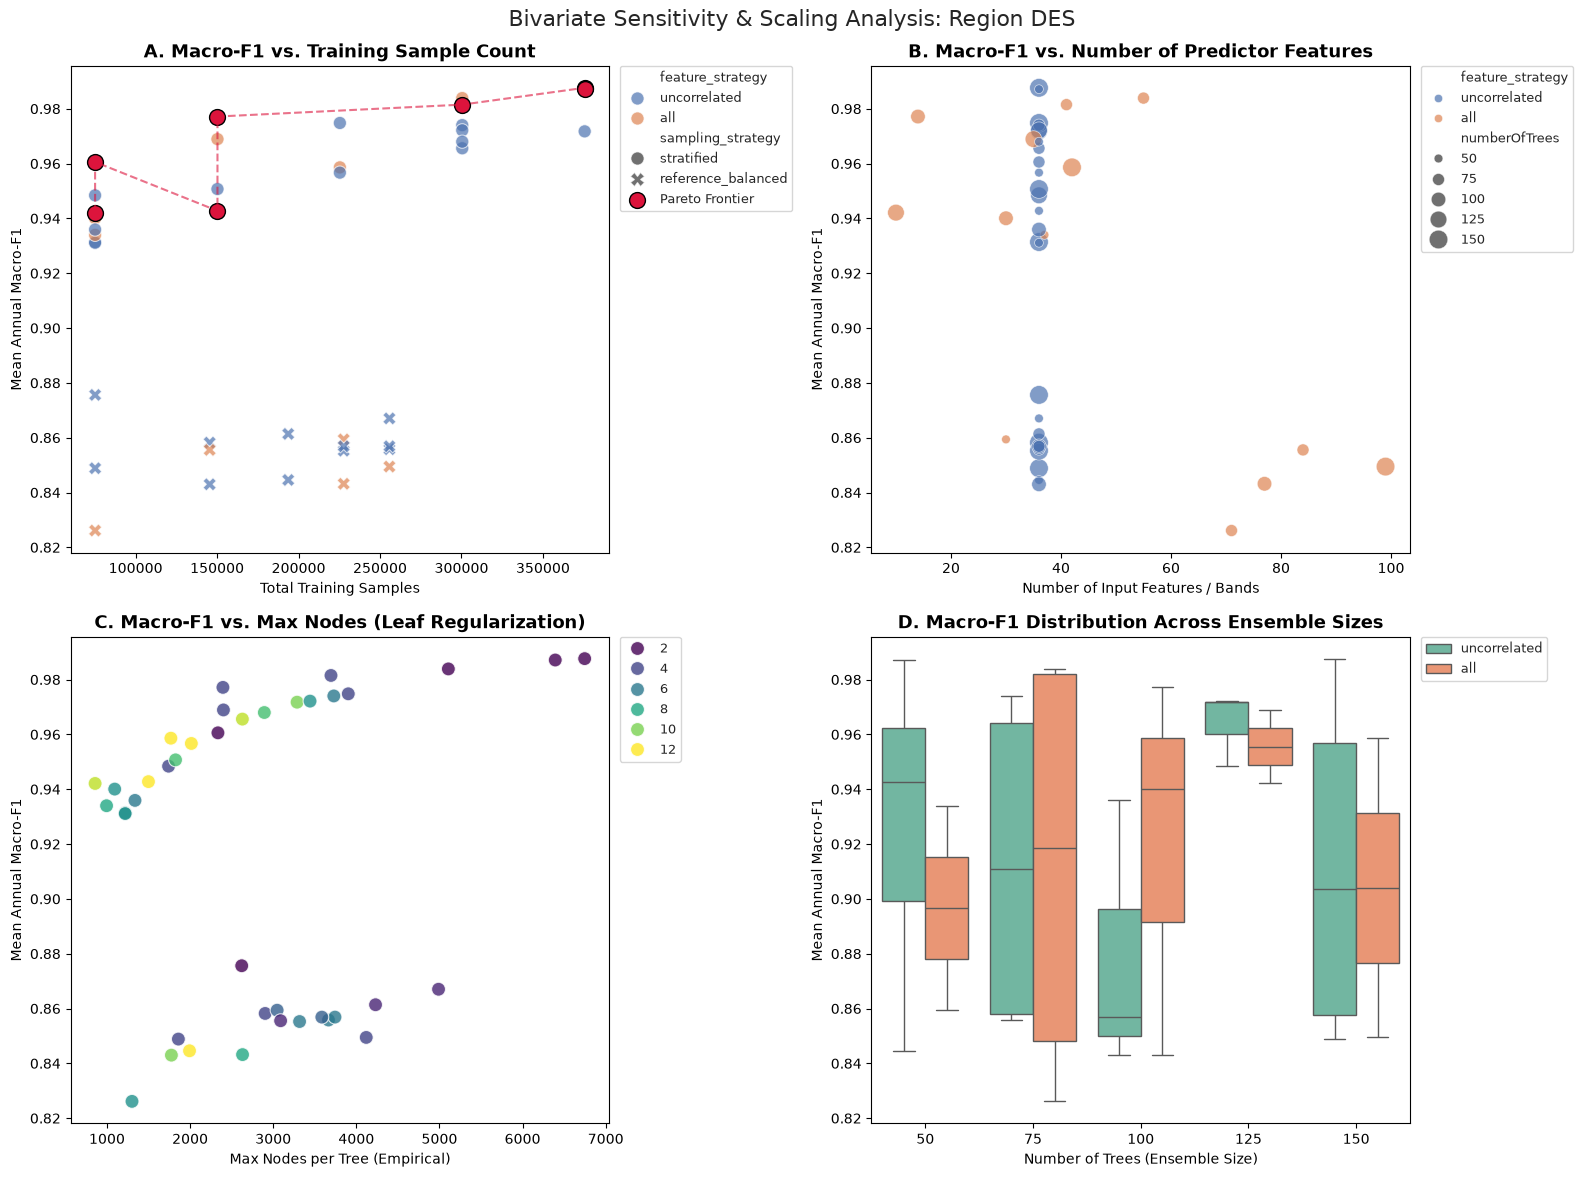

Bivariate dashboard saved -> data/optuna_regional_gee_configs/DES_bivariate_analysis.png


In [11]:
# --- Bivariate Tradeoff Visualizations ---

# 1. Compile trial records into a clean tabular DataFrame
records = []
for t in study.trials:
    if t.state.name == "COMPLETE":
        # Determine active features count
        strat = t.params.get("feature_strategy", "all")
        if strat == "uncorrelated":
            n_feats = len(uncorr_ranked)
        else:
            n_feats = t.params.get("max_input_features", len(all_ranked))

        records.append({
            "trial_number": t.number,
            "macro_f1": t.values[0],
            "model_complexity": t.values[1],
            "total_samples": t.user_attrs.get("total_samples"),
            "num_features": t.user_attrs.get("num_features", n_feats),
            "max_nodes": t.user_attrs.get("max_nodes"),
            "numberOfTrees": t.params.get("numberOfTrees"),
            "minLeafPopulation": t.params.get("minLeafPopulation"),
            "sampling_strategy": t.params.get("sampling_strategy"),
            "feature_strategy": strat,
            "train_fraction": t.params.get("train_fraction"),
            "is_pareto": t in study.best_trials
        })

df_trials = pd.DataFrame(records)

# 2. Build 2x2 Bivariate Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# Panel A: Macro-F1 vs. Training Sample Count
sns.scatterplot(
    data=df_trials,
    x="total_samples",
    y="macro_f1",
    hue="feature_strategy",
    style="sampling_strategy",
    s=90,
    alpha=0.7,
    ax=axes[0, 0]
)
# Highlight Pareto frontier
pareto_samples = df_trials[df_trials["is_pareto"]].sort_values("total_samples")
axes[0, 0].plot(pareto_samples["total_samples"], pareto_samples["macro_f1"], color="crimson", linestyle="--", alpha=0.6)
axes[0, 0].scatter(pareto_samples["total_samples"], pareto_samples["macro_f1"], color="crimson", s=130, edgecolor="black", label="Pareto Frontier")
axes[0, 0].set_title("A. Macro-F1 vs. Training Sample Count", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Total Training Samples")
axes[0, 0].set_ylabel("Mean Annual Macro-F1")

# Panel B: Macro-F1 vs. Number of Features
sns.scatterplot(
    data=df_trials,
    x="num_features",
    y="macro_f1",
    hue="feature_strategy",
    size="numberOfTrees",
    sizes=(40, 180),
    alpha=0.7,
    ax=axes[0, 1]
)
axes[0, 1].set_title("B. Macro-F1 vs. Number of Predictor Features", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("Number of Input Features / Bands")
axes[0, 1].set_ylabel("Mean Annual Macro-F1")

# Panel C: Macro-F1 vs. Empirical Max Nodes per Tree
sns.scatterplot(
    data=df_trials,
    x="max_nodes",
    y="macro_f1",
    hue="minLeafPopulation",
    palette="viridis",
    s=100,
    alpha=0.8,
    ax=axes[1, 0]
)
axes[1, 0].set_title("C. Macro-F1 vs. Max Nodes (Leaf Regularization)", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Max Nodes per Tree (Empirical)")
axes[1, 0].set_ylabel("Mean Annual Macro-F1")

# Panel D: Macro-F1 vs. Number of Trees
sns.boxplot(
    data=df_trials,
    x="numberOfTrees",
    y="macro_f1",
    hue="feature_strategy",
    palette="Set2",
    ax=axes[1, 1]
)
axes[1, 1].set_title("D. Macro-F1 Distribution Across Ensemble Sizes", fontsize=13, fontweight="bold")
axes[1, 1].set_xlabel("Number of Trees (Ensemble Size)")
axes[1, 1].set_ylabel("Mean Annual Macro-F1")

# Formatting & Saving
for ax in axes.flat:
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=9)

plt.suptitle(f"Bivariate Sensitivity & Scaling Analysis: Region {TARGET_REGION}", fontsize=16, y=0.98)
plt.tight_layout()

bivariate_plot_path = output_config_dir / f"{TARGET_REGION}_bivariate_analysis.png"
plt.savefig(bivariate_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Bivariate dashboard saved -> {bivariate_plot_path}")

In [13]:
# Print Pareto front summary and the trial with the highest Macro-F1
print(f"Number of trials on the Pareto front: {len(study.best_trials)}")

trial_with_highest_f1 = max(study.best_trials, key=lambda t: t.values[0])

print("Trial with highest Macro-F1:")
print(f"\tnumber: {trial_with_highest_f1.number}")
print(f"\tparams: {trial_with_highest_f1.params}")
print(f"\tvalues: [Macro-F1: {trial_with_highest_f1.values[0]:.4f}, Model Complexity: {trial_with_highest_f1.values[1]:.2e}]")
print(f"\tuser_attrs: {trial_with_highest_f1.user_attrs}")

Number of trials on the Pareto front: 7
Trial with highest Macro-F1:
	number: 16
	params: {'sampling_strategy': 'stratified', 'feature_strategy': 'uncorrelated', 'train_fraction': 1.0, 'minLeafPopulation': 2, 'numberOfTrees': 150}
	values: [Macro-F1: 0.9876, Model Complexity: 1.37e+13]
	user_attrs: {'total_samples': 375603, 'num_features': 36, 'max_nodes': 6747, 'model_complexity': 13684644581400.0}


In [14]:
trial_with_lowest_complexity = min(study.best_trials, key=lambda t: t.values[1])

print("\nTrial with lowest Model Complexity:")
print(f"\tnumber: {trial_with_lowest_complexity.number}")
print(f"\tparams: {trial_with_lowest_complexity.params}")
print(f"\tvalues: [Macro-F1: {trial_with_lowest_complexity.values[0]:.4f}, Model Complexity: {trial_with_lowest_complexity.values[1]:.2e}]")
print(f"\tuser_attrs: {trial_with_lowest_complexity.user_attrs}")


Trial with lowest Model Complexity:
	number: 15
	params: {'sampling_strategy': 'stratified', 'feature_strategy': 'all', 'max_input_features': 10, 'train_fraction': 0.2, 'minLeafPopulation': 11, 'numberOfTrees': 125}
	values: [Macro-F1: 0.9421, Model Complexity: 8.05e+10]
	user_attrs: {'total_samples': 75101, 'num_features': 10, 'max_nodes': 857, 'model_complexity': 80451946250.0}


In [12]:
# --- Hyperparameter Importance Analysis ---
from optuna.visualization import plot_param_importances

# 1. Parameter Importance for Objective 1: Mean Macro-F1
fig_importance_f1 = plot_param_importances(
    study,
    target=lambda t: t.values[0],
    target_name="Mean Macro-F1"
)
fig_importance_f1.update_layout(
    title=f"Hyperparameter Importance for Macro-F1 ({TARGET_REGION})",
    width=850,
    height=450
)
fig_importance_f1.show()

# 2. Parameter Importance for Objective 2: Model Complexity
fig_importance_complexity = plot_param_importances(
    study,
    target=lambda t: t.values[1],
    target_name="Model Complexity"
)
fig_importance_complexity.update_layout(
    title=f"Hyperparameter Importance for Model Complexity ({TARGET_REGION})",
    width=850,
    height=450
)
fig_importance_complexity.show()

# Optional: Export interactive HTMLs
fig_importance_f1.write_html(output_config_dir / f"{TARGET_REGION}_param_importance_f1.html")
fig_importance_complexity.write_html(output_config_dir / f"{TARGET_REGION}_param_importance_complexity.html")

In [15]:
# Cell 5: Compile & Export All Trial Performances to Disk

pareto_trial_numbers = set(t.number for t in study.best_trials)
all_trials_records = []

for t in study.trials:
    if t.state.name != "COMPLETE":
        continue
        
    feat_strategy = t.params.get("feature_strategy", "all")
    if feat_strategy == "uncorrelated":
        selected_bands = uncorr_ranked
        num_bands = len(selected_bands)
    else:
        num_bands = t.params.get("max_input_features", len(all_ranked))
        selected_bands = all_ranked[:num_bands]
        
    record = {
        "region": TARGET_REGION,
        "trial_number": t.number,
        "macro_f1": float(t.values[0]),
        "model_complexity": float(t.values[1]),
        "is_pareto": t.number in pareto_trial_numbers,
        "sampling_strategy": t.params.get("sampling_strategy", "stratified"),
        "feature_strategy": feat_strategy,
        "train_fraction": float(t.params.get("train_fraction", 1.0)),
        "numberOfTrees": int(t.params.get("numberOfTrees", 100)),
        "minLeafPopulation": int(t.params.get("minLeafPopulation", 2)),
        "num_input_features": int(num_bands),
        "variablesPerSplit": int(np.sqrt(num_bands)),
        "total_samples": t.user_attrs.get("total_samples"),
        "max_nodes": t.user_attrs.get("max_nodes"),
        "selected_bands": selected_bands
    }
    all_trials_records.append(record)

# 1. Save Tabular CSV (excluding raw list of bands for easy table inspection)
df_trials_summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != "selected_bands"} 
    for r in all_trials_records
])
csv_path = output_config_dir / f"{TARGET_REGION}_all_trials.csv"
df_trials_summary.to_csv(csv_path, index=False)

# 2. Save Full JSON (includes selected_bands list per trial)
json_path = output_config_dir / f"{TARGET_REGION}_all_trials.json"
with open(json_path, "w") as f:
    json.dump(all_trials_records, f, indent=2)

# Optional cleanup of scratch memory directory if not needed
# if cache_dir.exists():
#     shutil.rmtree(cache_dir, ignore_errors=True)

print(f"\n[Export Complete for {TARGET_REGION}]")
print(f"  Total completed trials saved: {len(all_trials_records)}")
print(f"  Pareto-optimal trials count:  {len(pareto_trial_numbers)}")
print(f"  Summary table saved to -> {csv_path}")
print(f"  Complete JSON saved to  -> {json_path}")


[Export Complete for DES]
  Total completed trials saved: 40
  Pareto-optimal trials count:  7
  Summary table saved to -> data/optuna_regional_gee_configs/DES_all_trials.csv
  Complete JSON saved to  -> data/optuna_regional_gee_configs/DES_all_trials.json


In [ ]:
# # Cell 5: Extract Best Trial & Export GEE Config
# pareto_trials = study.best_trials
# best_trial = max(pareto_trials, key=lambda t: t.values[0])

# best_strategy = best_trial.params["feature_strategy"]
# if best_strategy == "uncorrelated":
#     selected_bands = uncorr_ranked
#     num_bands = len(selected_bands)
# else:
#     num_bands = best_trial.params["max_input_features"]
#     selected_bands = all_ranked[:num_bands]

# region_summary = {
#     "region": TARGET_REGION,
#     "sampling_strategy": best_trial.params.get("sampling_strategy", "stratified"),
#     "feature_strategy": best_strategy,
#     "macro_f1": best_trial.values[0],
#     "model_complexity": best_trial.values[1],
#     "total_samples": best_trial.user_attrs.get("total_samples"),
#     "max_nodes": best_trial.user_attrs.get("max_nodes"),
#     "train_fraction": best_trial.params["train_fraction"],
#     "num_input_features": num_bands,
#     "numberOfTrees": best_trial.params["numberOfTrees"],
#     "variablesPerSplit": int(np.sqrt(num_bands)),
#     "minLeafPopulation": best_trial.params["minLeafPopulation"],
#     "selected_bands": selected_bands
# }

# config_path = output_config_dir / f"{TARGET_REGION}_best_params.json"
# with open(config_path, "w") as f:
#     json.dump(region_summary, f, indent=2)

# # Safely remove scratch folder without FileNotFoundError
# # if cache_dir.exists():
# #     shutil.rmtree(cache_dir, ignore_errors=True)

# print(f"\n[Finished {TARGET_REGION}]")
# print(f"  Best Feature Strategy:  {best_strategy} ({num_bands} features)")
# print(f"  Macro-F1: {region_summary['macro_f1']:.4f}")
# print(f"  Model Complexity: {region_summary['model_complexity']:.2e}")
# print(f"  Total Samples: {region_summary['total_samples']:,} | Max Nodes: {region_summary['max_nodes']}")
# print(f"  GEE configuration saved to -> {config_path}")


[Finished DES]
  Best Feature Strategy:  uncorrelated (36 features)
  Macro-F1: 0.9876
  Model Complexity: 1.37e+13
  Total Samples: 375,603 | Max Nodes: 6747
  GEE configuration saved to -> data/optuna_regional_gee_configs/DES_best_params.json
